In [106]:
import pandas as pd

df = pd.read_csv("cleaned_trend.csv")

df.head()

,post_id,title,category,score,num_comments,author,collected_at
0,47655408,Show HN: I built a tiny LLM to demystify how l...,technology,625,80,armanified,2026-04-06 13:16:06
1,47658146,France pulls last gold held in US for $15B gain,technology,279,155,teleforce,2026-04-06 13:16:06
2,47659807,Ask HN: How do systems (or people) detect when...,technology,19,16,elC0mpa,2026-04-06 13:16:07
3,47652007,"Show HN: Real-time AI (audio/video in, voice o...",technology,151,13,karimf,2026-04-06 13:16:07
4,47656981,"Drop, formerly Massdrop, ends most collaborati...",technology,60,17,stevebmark,2026-04-06 13:16:07


In [107]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   post_id       99 non-null     int64 
 1   title         99 non-null     object
 2   category      99 non-null     object
 3   score         99 non-null     int64 
 4   num_comments  99 non-null     int64 
 5   author        99 non-null     object
 6   collected_at  99 non-null     object
dtypes: int64(3), object(4)
memory usage: 5.5+ KB


(99, 7)

In [108]:
df.describe()

,post_id,score,num_comments
count,9.900000e+01,99.000000,99.000000
mean,4.764129e+07,170.595960,70.929293
std,1.567553e+04,238.498189,128.118508
min,4.759674e+07,3.000000,0.000000
25%,4.763370e+07,20.500000,6.000000
50%,4.764582e+07,73.000000,19.000000
75%,4.765355e+07,178.500000,79.000000
max,4.765981e+07,1080.000000,819.000000


In [109]:
# duplicates
df = df.drop_duplicates(subset="post_id")

# missing values
df.isnull().sum()
df["collected_at"] = pd.to_datetime(df["collected_at"])
df["title_length"] = df["title"].apply(len)

df["engagement"] = df["score"] + df["num_comments"]

#task 3

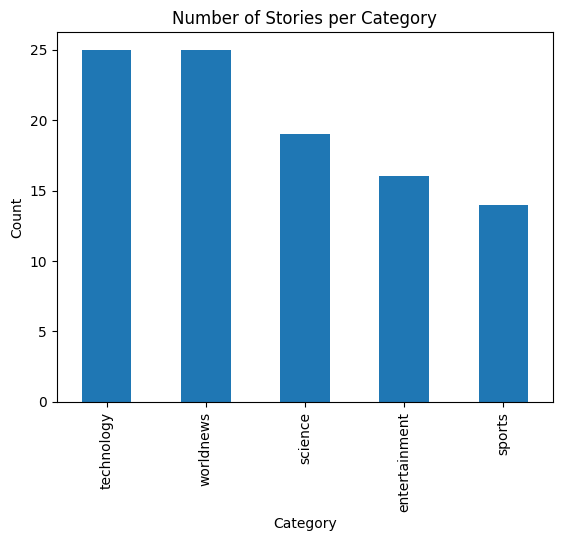

In [110]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar")
plt.title("Number of Stories per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

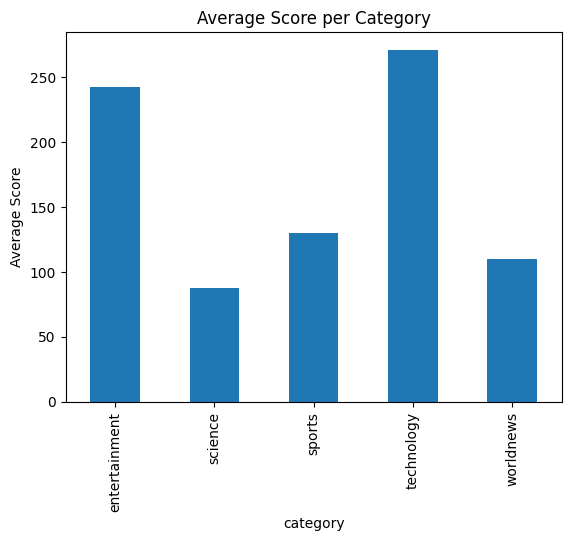

In [111]:
df.groupby("category")["score"].mean().plot(kind="bar")
plt.title("Average Score per Category")
plt.ylabel("Average Score")
plt.show()

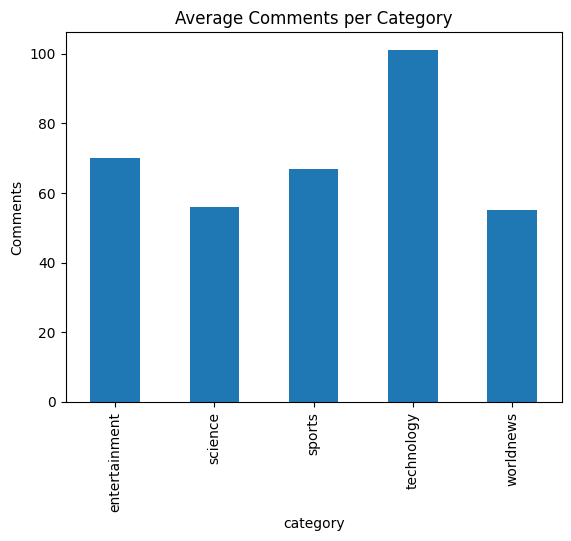

In [112]:
df.groupby("category")["num_comments"].mean().plot(kind="bar")
plt.title("Average Comments per Category")
plt.ylabel("Comments")
plt.show()

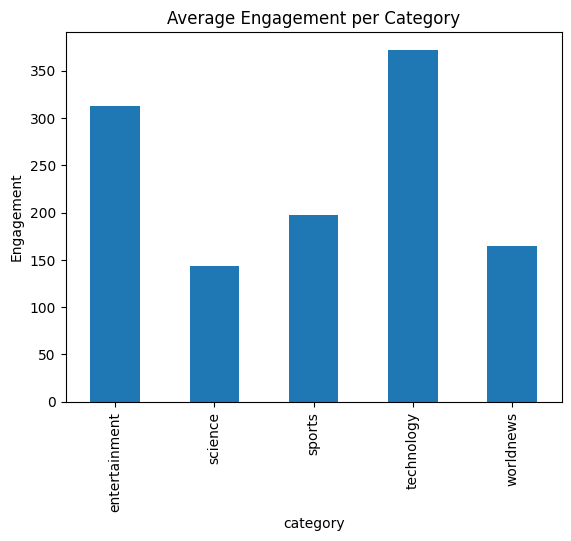

In [113]:
df.groupby("category")["engagement"].mean().plot(kind="bar")
plt.title("Average Engagement per Category")
plt.ylabel("Engagement")
plt.show()

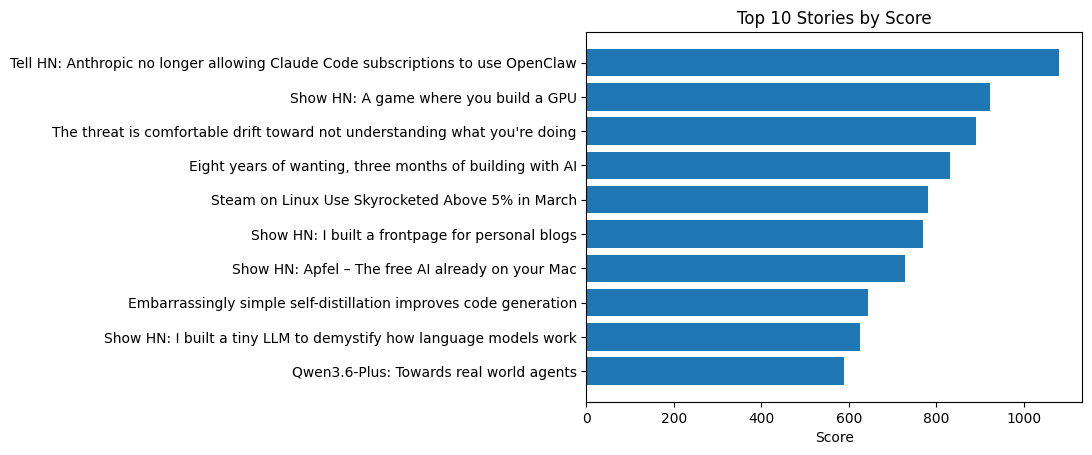

In [114]:
top_scores = df.sort_values(by="score", ascending=False).head(10)

plt.barh(top_scores["title"], top_scores["score"])
plt.title("Top 10 Stories by Score")
plt.xlabel("Score")
plt.gca().invert_yaxis()
plt.show()

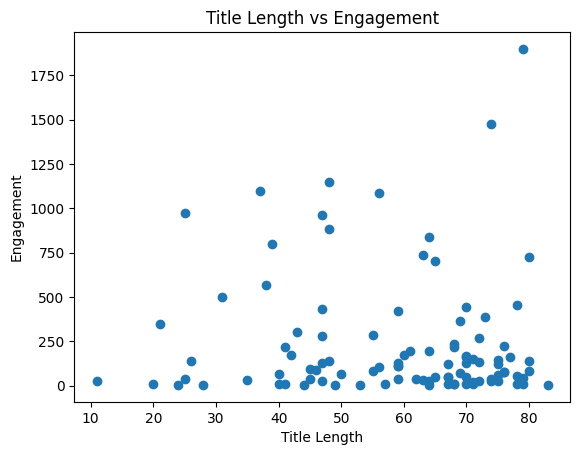

In [115]:
plt.scatter(df["title_length"], df["engagement"])
plt.title("Title Length vs Engagement")
plt.xlabel("Title Length")
plt.ylabel("Engagement")
plt.show()

Insights

Technology category has the highest number of posts.

Science and worldnews have fewer stories.

Some categories have higher engagement despite fewer posts.

High score posts generally have high engagement.

Title length does not strongly affect engagement.


In [116]:
print(df.columns)
print(df.shape)
df.info()

Index(['post_id', 'title', 'category', 'score', 'num_comments', 'author',
       'collected_at', 'title_length', 'engagement'],
      dtype='object')
(99, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   post_id       99 non-null     int64         
 1   title         99 non-null     object        
 2   category      99 non-null     object        
 3   score         99 non-null     int64         
 4   num_comments  99 non-null     int64         
 5   author        99 non-null     object        
 6   collected_at  99 non-null     datetime64[ns]
 7   title_length  99 non-null     int64         
 8   engagement    99 non-null     int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 7.1+ KB


In [117]:
df["title_length"] = df["title"].apply(len)
df["engagement"] = df["score"] + df["num_comments"]
df["comments_to_score_ratio"] = df["num_comments"] / (df["score"] + 1)

df[["title", "title_length", "engagement", "comments_to_score_ratio"]].head()

,title,title_length,engagement,comments_to_score_ratio
0,Show HN: I built a tiny LLM to demystify how l...,65,705,0.127796
1,France pulls last gold held in US for $15B gain,47,434,0.553571
2,Ask HN: How do systems (or people) detect when...,74,35,0.800000
3,"Show HN: Real-time AI (audio/video in, voice o...",77,164,0.085526
4,"Drop, formerly Massdrop, ends most collaborati...",76,77,0.278689


In [118]:
ml_df = df[["title", "category"]].copy()
ml_df = ml_df.dropna()
ml_df = ml_df.reset_index(drop=True)

print(ml_df.shape)
ml_df.head()

(99, 2)


,title,category
0,Show HN: I built a tiny LLM to demystify how l...,technology
1,France pulls last gold held in US for $15B gain,technology
2,Ask HN: How do systems (or people) detect when...,technology
3,"Show HN: Real-time AI (audio/video in, voice o...",technology
4,"Drop, formerly Massdrop, ends most collaborati...",technology


In [119]:
X = ml_df["title"]
y = ml_df["category"]

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [121]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (79, 419)
Testing shape: (20, 419)


In [122]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [123]:
y_pred = model.predict(X_test_tfidf)

In [124]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5

Classification Report:

               precision    recall  f1-score   support

entertainment       1.00      0.33      0.50         3
      science       1.00      0.50      0.67         4
       sports       0.00      0.00      0.00         3
   technology       0.33      0.80      0.47         5
    worldnews       0.60      0.60      0.60         5

     accuracy                           0.50        20
    macro avg       0.59      0.45      0.45        20
 weighted avg       0.58      0.50      0.48        20

Confusion Matrix:

[[1 0 0 2 0]
 [0 2 0 2 0]
 [0 0 0 2 1]
 [0 0 0 4 1]
 [0 0 0 2 3]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [125]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df

,entertainment,science,sports,technology,worldnews
entertainment,1,0,0,2,0
science,0,2,0,2,0
sports,0,0,0,2,1
technology,0,0,0,4,1
worldnews,0,0,0,2,3


#Test models

In [126]:
mixed_samples = [
    "AI helps scientists analyze space data from NASA missions",
    "Government uses data platform to track climate impact",
    "Sports league adopts computer vision for match analysis",
    "Streaming platform uses AI to recommend movies",
    "Researchers and software engineers build genome analysis tool",
    "President discusses technology policy in global summit",
    "Game developers use cloud GPUs to train new models",
    "Study finds music improves focus in students",
    "Team uses data science to improve player performance",
    "Film industry explores AI tools for video editing"
]

mixed_tfidf = vectorizer.transform(mixed_samples)
mixed_predictions = model.predict(mixed_tfidf)

for title, pred in zip(mixed_samples, mixed_predictions):
    print("Title:", title)
    print("Predicted category:", pred)
    print("-" * 60)

Title: AI helps scientists analyze space data from NASA missions
Predicted category: technology
------------------------------------------------------------
Title: Government uses data platform to track climate impact
Predicted category: worldnews
------------------------------------------------------------
Title: Sports league adopts computer vision for match analysis
Predicted category: worldnews
------------------------------------------------------------
Title: Streaming platform uses AI to recommend movies
Predicted category: worldnews
------------------------------------------------------------
Title: Researchers and software engineers build genome analysis tool
Predicted category: worldnews
------------------------------------------------------------
Title: President discusses technology policy in global summit
Predicted category: worldnews
------------------------------------------------------------
Title: Game developers use cloud GPUs to train new models
Predicted category: t

Machine Learning Extension:
The TrendPulse dataset was upgraded from rule-based categorization to supervised text classification.
Story titles were converted into numerical form using TF-IDF vectorization.
A Logistic Regression model was trained to predict the category of each post.
Additional engineered features such as title length, engagement, and comments-to-score ratio were also created for deeper analysis.


# STEP: Feature Engineering + ML


In [127]:
import pandas as pd

df = pd.read_csv("cleaned_trend.csv")
df.head()

,post_id,title,category,score,num_comments,author,collected_at
0,47655408,Show HN: I built a tiny LLM to demystify how l...,technology,625,80,armanified,2026-04-06 13:16:06
1,47658146,France pulls last gold held in US for $15B gain,technology,279,155,teleforce,2026-04-06 13:16:06
2,47659807,Ask HN: How do systems (or people) detect when...,technology,19,16,elC0mpa,2026-04-06 13:16:07
3,47652007,"Show HN: Real-time AI (audio/video in, voice o...",technology,151,13,karimf,2026-04-06 13:16:07
4,47656981,"Drop, formerly Massdrop, ends most collaborati...",technology,60,17,stevebmark,2026-04-06 13:16:07


In [128]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   post_id       99 non-null     int64 
 1   title         99 non-null     object
 2   category      99 non-null     object
 3   score         99 non-null     int64 
 4   num_comments  99 non-null     int64 
 5   author        99 non-null     object
 6   collected_at  99 non-null     object
dtypes: int64(3), object(4)
memory usage: 5.5+ KB


,post_id,score,num_comments
count,9.900000e+01,99.000000,99.000000
mean,4.764129e+07,170.595960,70.929293
std,1.567553e+04,238.498189,128.118508
min,4.759674e+07,3.000000,0.000000
25%,4.763370e+07,20.500000,6.000000
50%,4.764582e+07,73.000000,19.000000
75%,4.765355e+07,178.500000,79.000000
max,4.765981e+07,1080.000000,819.000000


In [129]:
df = df.drop_duplicates(subset="post_id")
df = df.dropna(subset=["title", "category"])
df["collected_at"] = pd.to_datetime(df["collected_at"])
df["title_length"] = df["title"].apply(len)
df["engagement"] = df["score"] + df["num_comments"]
df["comments_to_score_ratio"] = df["num_comments"] / (df["score"] + 1)

df.head()

,post_id,title,category,score,num_comments,author,collected_at,title_length,engagement,comments_to_score_ratio
0,47655408,Show HN: I built a tiny LLM to demystify how l...,technology,625,80,armanified,2026-04-06 13:16:06,65,705,0.127796
1,47658146,France pulls last gold held in US for $15B gain,technology,279,155,teleforce,2026-04-06 13:16:06,47,434,0.553571
2,47659807,Ask HN: How do systems (or people) detect when...,technology,19,16,elC0mpa,2026-04-06 13:16:07,74,35,0.800000
3,47652007,"Show HN: Real-time AI (audio/video in, voice o...",technology,151,13,karimf,2026-04-06 13:16:07,77,164,0.085526
4,47656981,"Drop, formerly Massdrop, ends most collaborati...",technology,60,17,stevebmark,2026-04-06 13:16:07,76,77,0.278689


In [130]:
ml_df = df[["title", "category"]].copy()
ml_df = ml_df.dropna()
ml_df = ml_df.reset_index(drop=True)

print(ml_df.shape)
ml_df.head()

(99, 2)


,title,category
0,Show HN: I built a tiny LLM to demystify how l...,technology
1,France pulls last gold held in US for $15B gain,technology
2,Ask HN: How do systems (or people) detect when...,technology
3,"Show HN: Real-time AI (audio/video in, voice o...",technology
4,"Drop, formerly Massdrop, ends most collaborati...",technology


In [131]:
X = ml_df["title"]
y = ml_df["category"]

In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [133]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (79, 419)
Testing shape: (20, 419)


In [134]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [135]:
y_pred = model.predict(X_test_tfidf)

In [136]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5

Classification Report:

               precision    recall  f1-score   support

entertainment       1.00      0.33      0.50         3
      science       1.00      0.50      0.67         4
       sports       0.00      0.00      0.00         3
   technology       0.33      0.80      0.47         5
    worldnews       0.60      0.60      0.60         5

     accuracy                           0.50        20
    macro avg       0.59      0.45      0.45        20
 weighted avg       0.58      0.50      0.48        20

Confusion Matrix:

[[1 0 0 2 0]
 [0 2 0 2 0]
 [0 0 0 2 1]
 [0 0 0 4 1]
 [0 0 0 2 3]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [137]:
all_tfidf = vectorizer.transform(df["title"])
df["predicted_category"] = model.predict(all_tfidf)

df[["title", "category", "predicted_category"]].head()

,title,category,predicted_category
0,Show HN: I built a tiny LLM to demystify how l...,technology,technology
1,France pulls last gold held in US for $15B gain,technology,technology
2,Ask HN: How do systems (or people) detect when...,technology,technology
3,"Show HN: Real-time AI (audio/video in, voice o...",technology,worldnews
4,"Drop, formerly Massdrop, ends most collaborati...",technology,technology


In [138]:
df.to_csv("trendpulse_ml_feature.csv", index=False)
print("Saved successfully")

Saved successfully
